# EDA analisis exploratorio pre-alineamiento

In [12]:
import os
import sys

root = os.path.abspath('..')

# Si la ruta no está en el sistema, la añadimos
if root not in sys.path:
    sys.path.append(root)

import pandas as pd
from Bio.SeqUtils import gc_fraction
from Bio import SeqIO
from Bio.Seq import Seq
from Bio import AlignIO
from src.logger import logger
import json
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import math
import numpy as np
import itertools

In [13]:

with open("../dataConfig.json", "r") as config_file:
    config = json.load(config_file)
        
records= SeqIO.parse("../data/processed/sequences_filtered.fasta", "fasta")

alignments= AlignIO.read("../data/processed/alignment.fasta", "fasta")

        


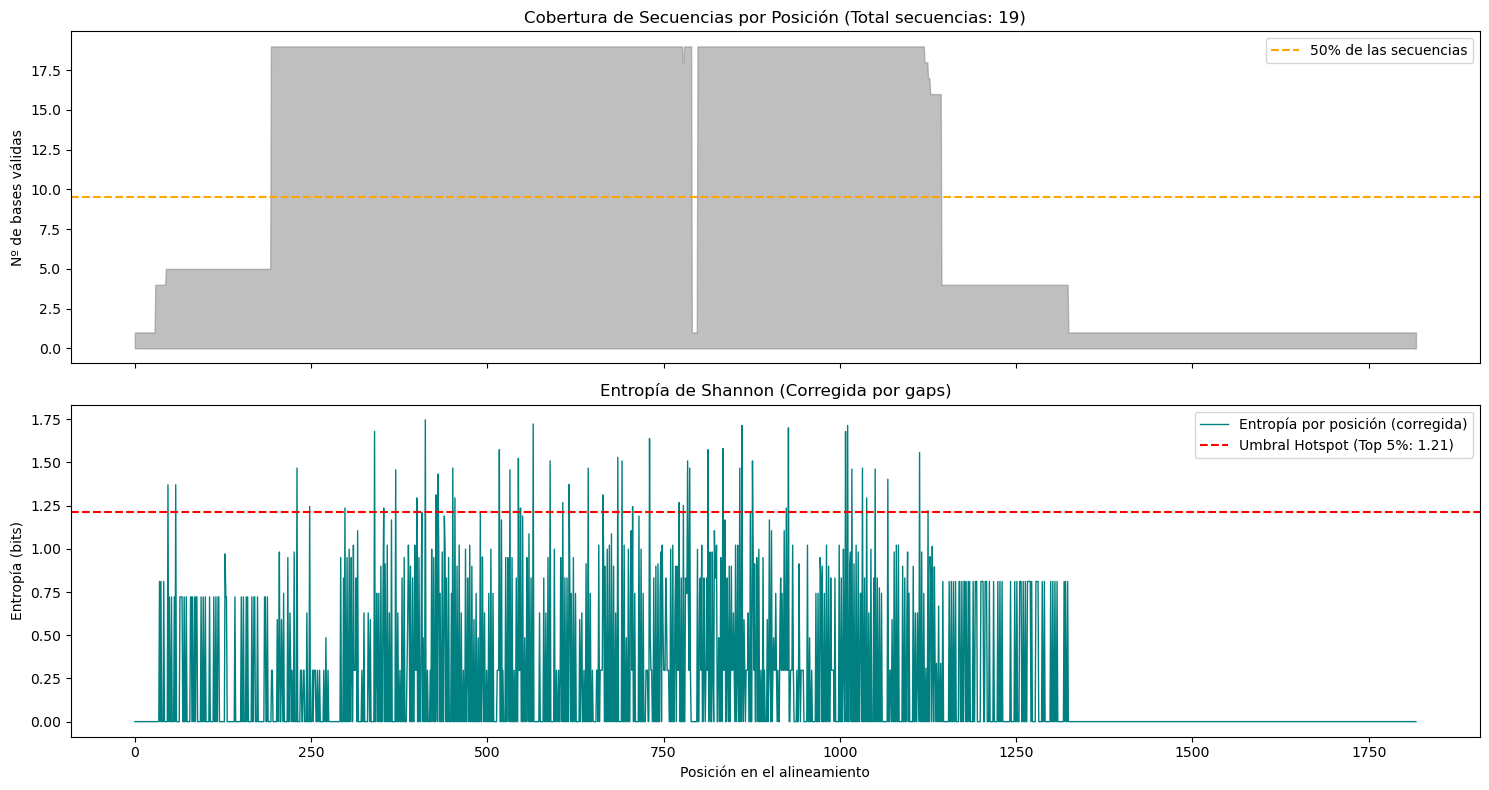

In [ ]:
def calculate_entropy_and_coverage(alignment):
    alignment_length = alignment.get_alignment_length() 
    entropies = []
    coverages = []
    
    for i in range(alignment_length):
        column = alignment[:, i].upper()
        counts = Counter(column)
    
        valid_bases = sum(count for base, count in counts.items() if base not in ['-', 'N'])
        coverages.append(valid_bases)
    
        entropy = 0
        if valid_bases > 0:
            for base, count in counts.items():
                if base not in ['-', 'N']: 
                    freq = count / valid_bases 
                    entropy -= freq * math.log2(freq)
        entropies.append(entropy)
        
    return np.array(entropies), np.array(coverages)

entropies, coverages = calculate_entropy_and_coverage(alignments)
total_seqs = len(alignments)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax1.fill_between(range(len(coverages)), coverages, color='gray', alpha=0.5)
ax1.axhline(y=total_seqs * 0.5, color='orange', linestyle='--', label='50% de las secuencias')
ax1.set_title(f'Cobertura de Secuencias por Posición (Total secuencias: {total_seqs})')
ax1.set_ylabel('Nº de bases válidas')
ax1.legend()


ax2.plot(entropies, color='teal', linewidth=1, label='Entropía por posición (corregida)')
posiciones_fiables = entropies[coverages > (total_seqs * 0.5)]
if len(posiciones_fiables) > 0:
    umbral_hotspot = np.percentile(posiciones_fiables, 95)
    ax2.axhline(y=umbral_hotspot, color='red', linestyle='--', label=f'Umbral Hotspot (Top 5%: {umbral_hotspot:.2f})')

ax2.set_title('Entropía de Shannon (Corregida por gaps)')
ax2.set_xlabel('Posición en el alineamiento')
ax2.set_ylabel('Entropía (bits)')
ax2.legend()

plt.tight_layout()
plt.show()

Length
943     12
1287     3
927      1
924      1
1068     1
Name: count, dtype: int64
 0 anomalous sequences beacuse GC (Outliers) detected.


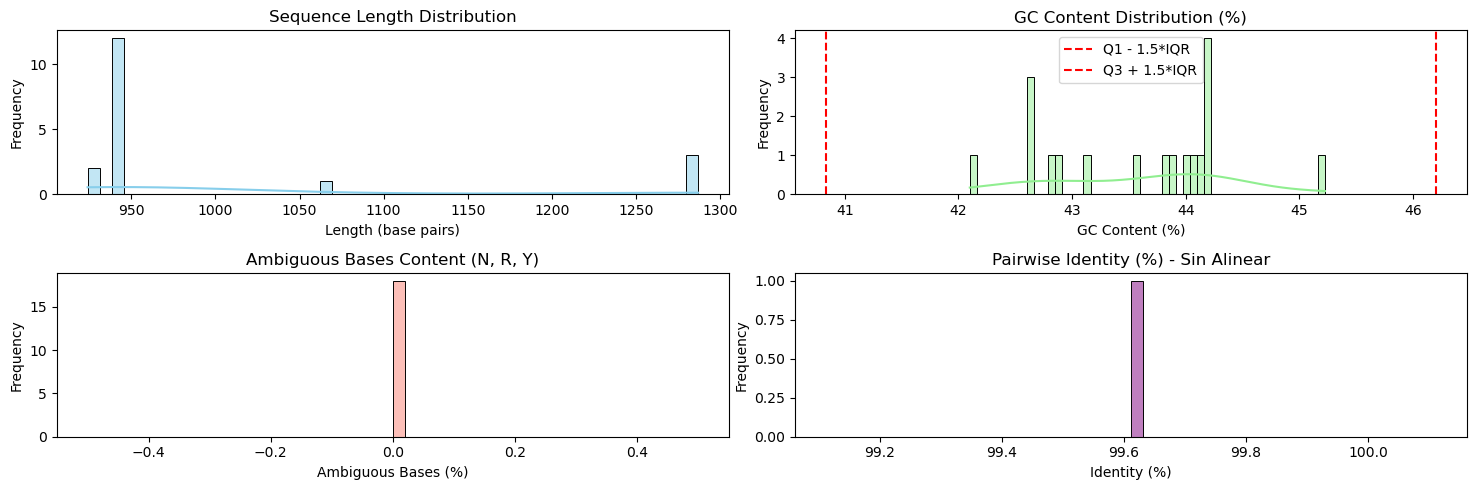

In [17]:
records= SeqIO.parse("../data/processed/sequences_filtered.fasta", "fasta")

seq_data = []
sequences_str = []
for record in records:
    seq_len = len(record.seq)
    seq_str = str(record.seq).upper()
    sequences_str.append(seq_str)
    ambiguous_count = seq_str.count('N') + seq_str.count('R') + seq_str.count('Y')
    ambiguous_perc = (ambiguous_count / seq_len) * 100 if seq_len > 0 else 0
    gc_content = gc_fraction(record.seq) * 100 
    seq_data.append({"ID": record.id, "Length": seq_len, "GC_Content": gc_content, "Ambiguous_Perc": ambiguous_perc})

df_seqs = pd.DataFrame(seq_data)
print(df_seqs['Length'].value_counts())

Q1 = df_seqs["GC_Content"].quantile(0.25)
Q3 = df_seqs["GC_Content"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_seqs['GC_Outlier'] = (df_seqs['GC_Content'] < lower_bound) | (df_seqs['GC_Content'] > upper_bound)
num_outliers = df_seqs['GC_Outlier'].sum()
print(f" {num_outliers} anomalous sequences beacuse GC (Outliers) detected.")

pairwise_identities = []
for seq1, seq2 in itertools.combinations(sequences_str, 2):
    min_len = min(len(seq1), len(seq2))
    matches= 0
    for a, b in zip(seq1, seq2):
        if a==b:
            matches+=1
identity = (matches / min_len) * 100
pairwise_identities.append(identity)

fig, axes = plt.subplots(2, 2, figsize=(15, 5))
axes = axes.flatten()

# 1. Sequence Length Distribution
sns.histplot(df_seqs["Length"], bins=50, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Sequence Length Distribution')
axes[0].set_xlabel('Length (base pairs)')
axes[0].set_ylabel('Frequency')

# 2. GC Content Distribution
sns.histplot(df_seqs['GC_Content'], bins=50, kde=True, ax=axes[1], color='lightgreen')
axes[1].axvline(lower_bound, color='red', linestyle='dashed', linewidth=1.5, label='Q1 - 1.5*IQR')
axes[1].axvline(upper_bound, color='red', linestyle='dashed', linewidth=1.5, label='Q3 + 1.5*IQR')
axes[1].set_title('GC Content Distribution (%)')
axes[1].set_xlabel('GC Content (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

# 3. Ambiguous Bases Content
sns.histplot(df_seqs['Ambiguous_Perc'], bins=50, kde=True, ax=axes[2], color='salmon')
axes[2].set_title('Ambiguous Bases Content (N, R, Y)')
axes[2].set_xlabel('Ambiguous Bases (%)')
axes[2].set_ylabel('Frequency')

# 4. Pairwise identitie
sns.histplot(pairwise_identities, bins=50, kde=True, ax=axes[3], color='purple')
axes[3].set_title('Pairwise Identity (%) - Sin Alinear')
axes[3].set_xlabel('Identity (%)')
axes[3].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
def shannon_entropy(alignments):
    alignment_length = len(alignments[0].seq)
    num_seqs = len(alignments)
    entropies = []
    for i in range(alignment_length):
        column = [record.seq[i].upper() for record in alignments]
        counts = Counter(column)
        entropy = 0
        for base, count in counts.items():
            if base not in ['-', 'N']: 
                freq = count / num_seqs
                if freq > 0:
                    entropy -= freq * math.log2(freq)
        entropies.append(entropy)
    return entropies

entropies= shannon_entropy(alignments)
entropies_array = np.array(entropies)
umbral_hotspot = np.percentile(entropies_array, 95)

TypeError: 'generator' object is not subscriptable

: 